In [1]:
import nibabel as nib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from skimage.util import montage
from skimage.transform import rotate
import nilearn
from nilearn import image, masking
import pytorch_lightning as pl
#from pl_bolts.models.self_supervised import SwAV
#from lightning_bolts.datamodules import RandomDataset

In [2]:
data_dir = '../post/'
trn_dir = data_dir+'PatientID_0003/Timepoint_1/'
val_dir = data_dir+'BraTS2021_ValidationSet/UPENN-GBM/'

In [3]:
test_flair = nib.load(trn_dir+'PatientID_0003_Timepoint_1_brain_t2f.nii.gz').get_fdata()
print(f'Shape:  {test_flair.shape}')
print(f'Dtype:  {test_flair.dtype}')

Shape:  (240, 240, 155)
Dtype:  float64


In [4]:
print(f'Min: {test_flair.min()}')
print(f'Max: {test_flair.max()}')

Min: 0.0
Max: 905.3739624023438


The above code snippet indicates the maximum pixel value of the image is 625 which provides a good case to rescale these values

In [5]:
scaler = MinMaxScaler()
test_flair = scaler.fit_transform(test_flair.reshape(-1, test_flair.shape[-1])).reshape(test_flair.shape)
print(f'Min: {test_flair.min()}')
print(f'Max: {test_flair.max()}')

Min: 0.0
Max: 1.0


Bruit force load and scale the images from the nifti files

In [6]:
flair = nib.load(trn_dir+'PatientID_0003_Timepoint_1_brain_t2f.nii.gz').get_fdata()
t1    = nib.load(trn_dir+'PatientID_0003_Timepoint_1_brain_t1n.nii.gz').get_fdata()
t1ce  = nib.load(trn_dir+'PatientID_0003_Timepoint_1_brain_t1c.nii.gz').get_fdata()
t2    = nib.load(trn_dir+'PatientID_0003_Timepoint_1_brain_t2w.nii.gz').get_fdata()
seg   = nib.load(trn_dir+'PatientID_0003_Timepoint_1_tumorMask.nii.gz').get_fdata()

flair = scaler.fit_transform(flair.reshape(-1, flair.shape[-1])).reshape(flair.shape)
t1    = scaler.fit_transform(t1.reshape(-1, t1.shape[-1])).reshape(t1.shape)
t1ce  = scaler.fit_transform(t1ce.reshape(-1, t1ce.shape[-1])).reshape(t1ce.shape)
t2    = scaler.fit_transform(t2.reshape(-1, t2.shape[-1])).reshape(t2.shape)

See what they look like

Slice Number: 70


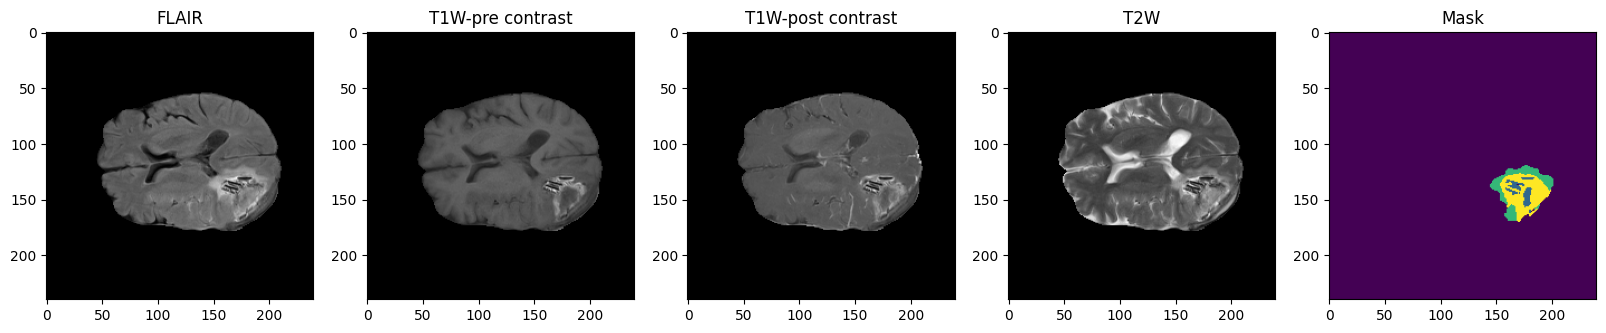

In [28]:
slice = 70
print(f'Slice Number: {slice}')

plt.figure(figsize=(20, 20))

# Flair
plt.subplot(2, 5, 1)
plt.imshow(flair[:,:,slice], cmap='gray')
plt.title('FLAIR')

# T1
plt.subplot(2, 5, 2)
plt.imshow(t1[:,:,slice], cmap='gray')
plt.title('T1W-pre contrast')

# T1CE
plt.subplot(2, 5, 3)
plt.imshow(t1ce[:,:,slice], cmap='gray')
plt.title('T1W-post contrast')

# T2
plt.subplot(2, 5, 4)
plt.imshow(t2[:,:,slice], cmap='gray')
plt.title('T2W')

# Mask
plt.subplot(2, 5, 5)
plt.imshow(seg[:,:,slice])
plt.title('Mask')

plt.show()

In [18]:
print(f'Modality:     {t1.shape}')
print(f'Segmentation: {seg.shape}')

Modality:     (240, 240, 155)
Segmentation: (240, 240, 155)


Each image has three different dimensions which means there are three different planes for each slice.  I will look at them

- **Axial (Transverse) Plane**: This plane divides the body into upper and lower parts and is perpendicular to the long axis of the body. In brain imaging, the axial slice is a horizontal cut through the brain
- **Coronal (Frontal) Plane**: This plane divides the body into front (anterior) and back (posterior) parts.  A coronal slice in brain imaging is a vertical cut from one side of the head to the other, dividing the front and back sections
- **Sagittal (Lateral) Plane**: This plane divides the body into left and right parts.  A sagittal slice in brain imaging is a vertical cut from front to back, dividing the body into left and right sections.

Slice number: 95


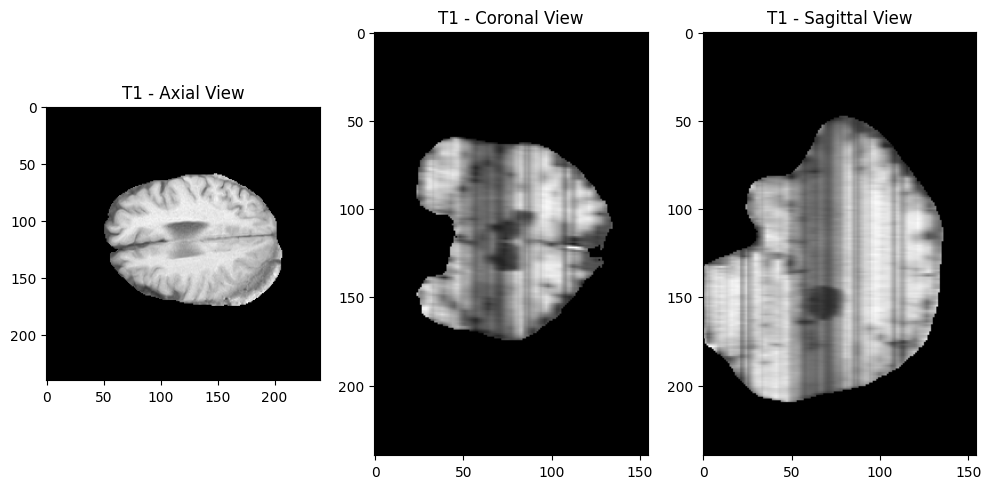

In [9]:
slice = 95
print(f'Slice number: {slice}')

plt.figure(figsize=(12, 8))

# Apply a 90 degree rotation
# T1 - Transverse view
plt.subplot(1, 3, 1)
plt.imshow(t1[:,:,slice], cmap='gray')
plt.title('T1 - Axial View')

# T1 - Frontal view
plt.subplot(1, 3, 2)
plt.imshow(t1[:,slice,:], cmap='gray')
plt.title('T1 - Coronal View')

# T1 - Sagittal view
plt.subplot(1, 3, 3)
plt.imshow(t1[slice,:,:], cmap='gray')
plt.title('T1 - Sagittal View')

plt.show()

Look at what ***segmentation*** provides
1. **Location**: Identifies exact location of the brain tumor
2. **Size and Shape**: Measures the tumor's dimensions and form
3. **Heterogeneity**: Reveals different components within the tumor (e.g. solid tissue, necrotic areas)
4. **Surrounding Tissue Involvement**: Shows how the tumor interacts with adjacent brain structures
5. **Cross-Modality Comparison**: Provides a comprehensive view by comparing different imaging modalities

Plot the segmentation

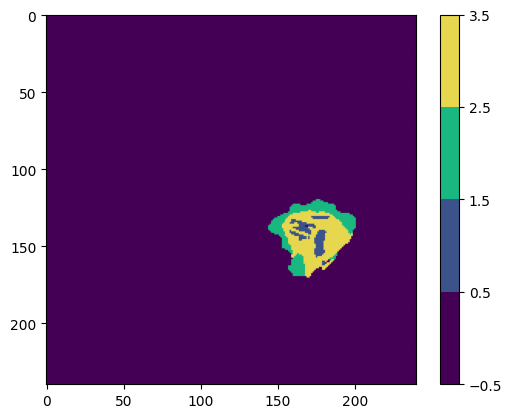

In [10]:
cmap = matplotlib.colors.ListedColormap(['#440054', '#3b528b', '#18b880', '#e6d74f'])
norm = matplotlib.colors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)

plt.imshow(seg[:,:,70], cmap=cmap, norm=norm)
plt.colorbar()
plt.show()

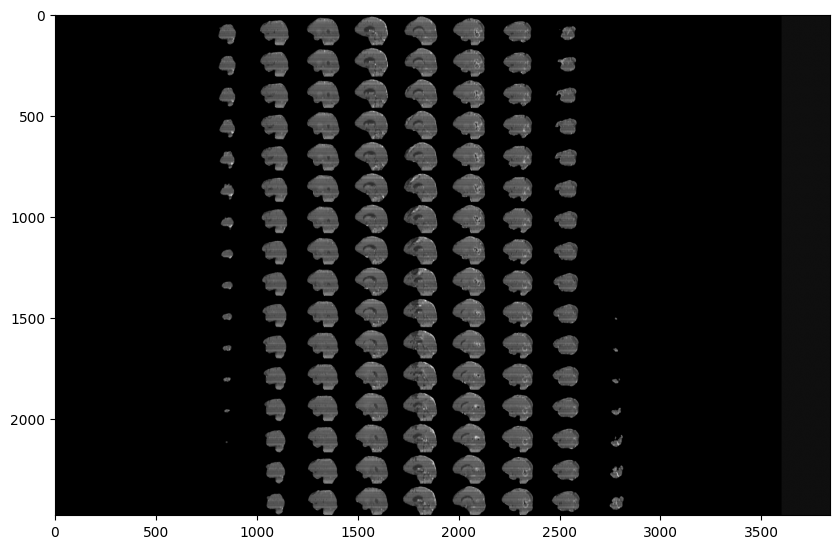

In [11]:
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)

plt.imshow(rotate(montage(t1ce[:,:,:]), 90, resize=True), cmap='gray')

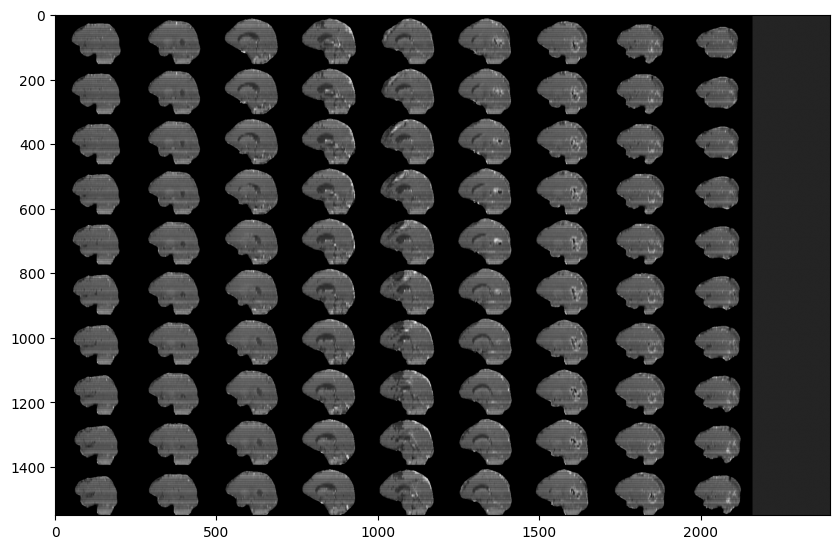

In [12]:
# Skip slices where there is not much to see
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)
plt.imshow(rotate(montage(t1ce[75:-75,:,:]), 90, resize=True), cmap='gray')

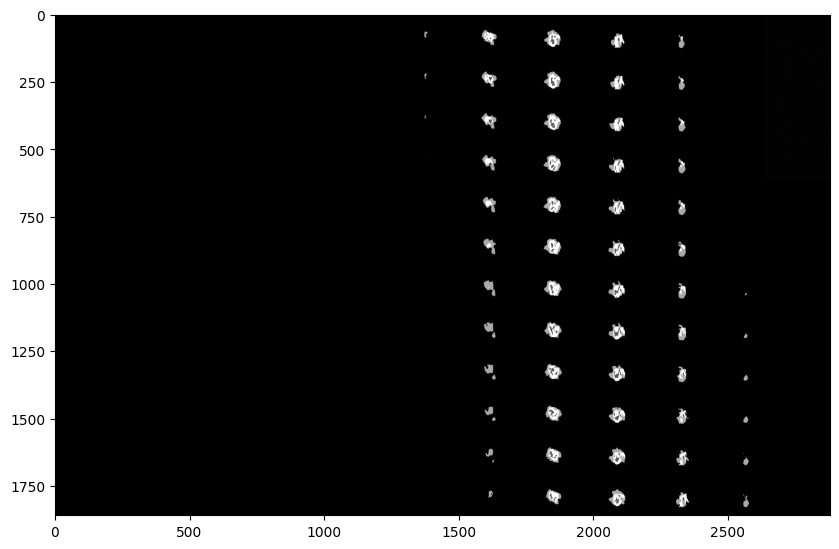

In [13]:
# Skip 50:-50 slices since there is notmuch to see
plt.figure(figsize=(10, 10))
plt.subplot(1, 1, 1)
plt.imshow(rotate(montage(seg[50:-50:,:]), 90, resize=True), cmap='gray')

Annotations (labels):
1. **Label 0**: Not Tumor (NT) volume
2. **Label 1**: Necrotic and non-enhancing tumor core (NCR/NET)
3. **Label 2**: Peritumoral edema (ED)
4. **Label 3**: Missing in this dataset (there are no pixels in all of the volumes that has this label)
5. **Label 4**: GD-enhancing tumor (ET)

I will isolate the different labels (classes)

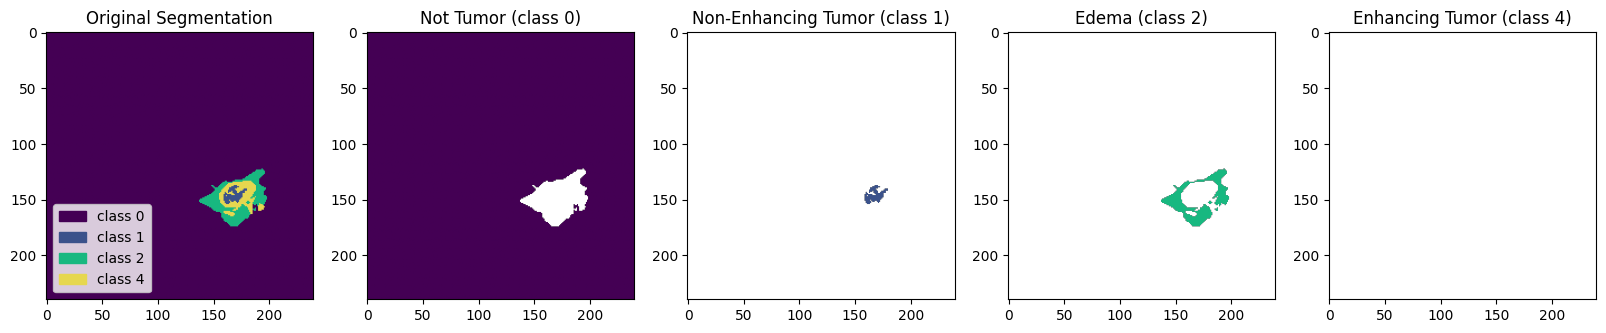

In [16]:
# Isolation of class 0
seg_0 = seg.copy()
seg_0[seg_0 != 0] = np.nan

# Isolation of class 1
seg_1 = seg.copy()
seg_1[seg_1 != 1] = np.nan

# Isolation of class 2
seg_2 = seg.copy()
seg_2[seg_2 != 2] = np.nan

# Isolation of class 3
seg_3 = seg.copy()
seg_3[seg_3 != 3] = np.nan

# There were no class 3 pixels
seg_4 = seg.copy()
seg_4[seg_4 != 4] = np.nan

# Plot classes
class_names = ['class 0', 'class 1', 'class 2', 'class 4']
legend = [plt.Rectangle((0, 0), 1, 1, color=cmap(i), label=class_names[i]) for i in range(len(class_names))]

fig, ax = plt.subplots(1, 5, figsize=(20, 20))

ax[0].imshow(seg[:,:,50], cmap=cmap, norm=norm)
ax[0].set_title('Original Segmentation')
ax[0].legend(handles=legend, loc='lower left')

ax[1].imshow(seg_0[:,:,50], cmap=cmap, norm=norm)
ax[1].set_title('Not Tumor (class 0)')

ax[2].imshow(seg_1[:,:,50], cmap=cmap, norm=norm)
ax[2].set_title('Non-Enhancing Tumor (class 1)')

ax[3].imshow(seg_2[:,:,50], cmap=cmap, norm=norm)
ax[3].set_title('Edema (class 2)')

ax[4].imshow(seg_4[:,:,50], cmap=cmap, norm=norm)
ax[4].set_title('Enhancing Tumor (class 4)')

plt.show()